# EDA: корпус «Наукограды России»

Разведочный анализ корпуса и графов (legacy, конструктор, GraphRAG baseline).

- **Отчёт:** [`docs/eda_report.md`](docs/eda_report.md)
- **Навигатор по проекту:** [`docs/project_guide.md`](docs/project_guide.md)
- **Автогенерация артефактов:** `python scripts/run_eda.py` → `output/eda/`

In [17]:
import json
import subprocess
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Image, display, Markdown

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)

ROOT = Path(".").resolve()
CORPUS = ROOT / "data/raw/naukogrady/documents.json"
OUT = ROOT / "output/eda"
FIG = OUT / "figures"
PATHS = {
    "legacy": (ROOT / "data/graphs/naukogrady/nodes.csv", ROOT / "data/graphs/naukogrady/edges.csv"),
    "constructor": (
        ROOT / "data/graphs/naukogrady/constructor/discourse/nodes.csv",
        ROOT / "data/graphs/naukogrady/constructor/discourse/edges.csv",
    ),
    "baseline": (
        ROOT / "data/graphs/naukogrady/constructor/graphrag_baseline/nodes.csv",
        ROOT / "data/graphs/naukogrady/constructor/graphrag_baseline/edges.csv",
    ),
}

## 0. Обновить артефакты EDA (опционально)

Пересоздаёт фигуры, JSON и проверки адекватности в `output/eda/`.

In [18]:
RUN_EDA = True  # поставьте False, если артефакты уже свежие

if RUN_EDA:
    r = subprocess.run([sys.executable, str(ROOT / "scripts/run_eda.py")], cwd=ROOT, capture_output=True, text=True)
    print(r.stdout)
    if r.returncode != 0:
        print(r.stderr)

EDA сохранён в /Users/amandrov/Институт/sna/output/eda
Проверки: 14/14 OK
  ✓ corpus_size: документов: 221
  ✓ median_text_len: медиана длины: 1975
  ✓ title_relevance: «наукоград» в заголовке: 117 док.
  ✓ city_metadata: документов с городом: 167
  ✓ ner_present: медиана NER/док: 20
  ✓ top_ner_domain: доменных сущностей в топ-20: 10
  ✓ keywords_domain: доменных kw в топ-50: 12; примеры: автор текста сколково россии главная общество российской федерации фото московск…
  ✓ legacy_cooccurrence_not_dense: legacy_cooccurrence: 2.51 рёбер/узел (цель ≤3–4)
  ✓ legacy_cooccurrence_has_edges: legacy_cooccurrence: 317 рёбер
  ✓ constructor_not_dense: constructor: 2.05 рёбер/узел (цель ≤3–4)
  ✓ constructor_has_edges: constructor: 216 рёбер
  ✓ graphrag_baseline_not_dense: graphrag_baseline: 2.66 рёбер/узел (цель ≤3–4)
  ✓ graphrag_baseline_has_edges: graphrag_baseline: 271 рёбер
  ✓ constructor_pmi: медиана PMI: 6.0062



## 1. Проверки адекватности (sanity checks)

In [19]:
sanity = json.loads((OUT / "sanity_checks.json").read_text(encoding="utf-8"))
corpus_stats = json.loads((OUT / "corpus_stats.json").read_text(encoding="utf-8"))
graph_metrics = json.loads((OUT / "graph_metrics.json").read_text(encoding="utf-8"))

df_checks = pd.DataFrame(sanity["checks"])
display(df_checks)
print(f"\nИтого: {sanity['passed']}/{sanity['total']} проверок пройдено")
assert sanity["passed"] >= sanity["total"] - 1, "Слишком много провалов — проверьте корпус"

,check,ok,detail
0,corpus_size,True,документов: 221
1,median_text_len,True,медиана длины: 1975
2,title_relevance,True,«наукоград» в заголовке: 117 док.
3,city_metadata,True,документов с городом: 167
4,ner_present,True,медиана NER/док: 20
5,top_ner_domain,True,доменных сущностей в топ-20: 10
6,keywords_domain,True,доменных kw в топ-50: 12; примеры: автор текст...
7,legacy_cooccurrence_not_dense,True,legacy_cooccurrence: 2.51 рёбер/узел (цель ≤3–4)
8,legacy_cooccurrence_has_edges,True,legacy_cooccurrence: 317 рёбер
9,constructor_not_dense,True,constructor: 2.05 рёбер/узел (цель ≤3–4)



Итого: 14/14 проверок пройдено


## 2. Корпус: сводка

In [20]:
with open(CORPUS, encoding="utf-8") as f:
    docs = json.load(f)
df = pd.DataFrame(docs)
df["text_len"] = df["text"].str.len()

display(Markdown(f"""
| Метрика | Значение |
|---------|----------|
| Документов | {corpus_stats['n_docs']} |
| Символов | {corpus_stats['total_chars']:,} |
| Медиана длины | {corpus_stats['median_text_len']:.0f} |
| С городом | {corpus_stats['n_with_city']} |
"""))

pd.DataFrame(corpus_stats["voice_type"].items(), columns=["voice_type", "count"])


| Метрика | Значение |
|---------|----------|
| Документов | 221 |
| Символов | 882,018 |
| Медиана длины | 1975 |
| С городом | 167 |


,voice_type,count
0,media,205
1,analytics,12
2,official,2
3,interview,2


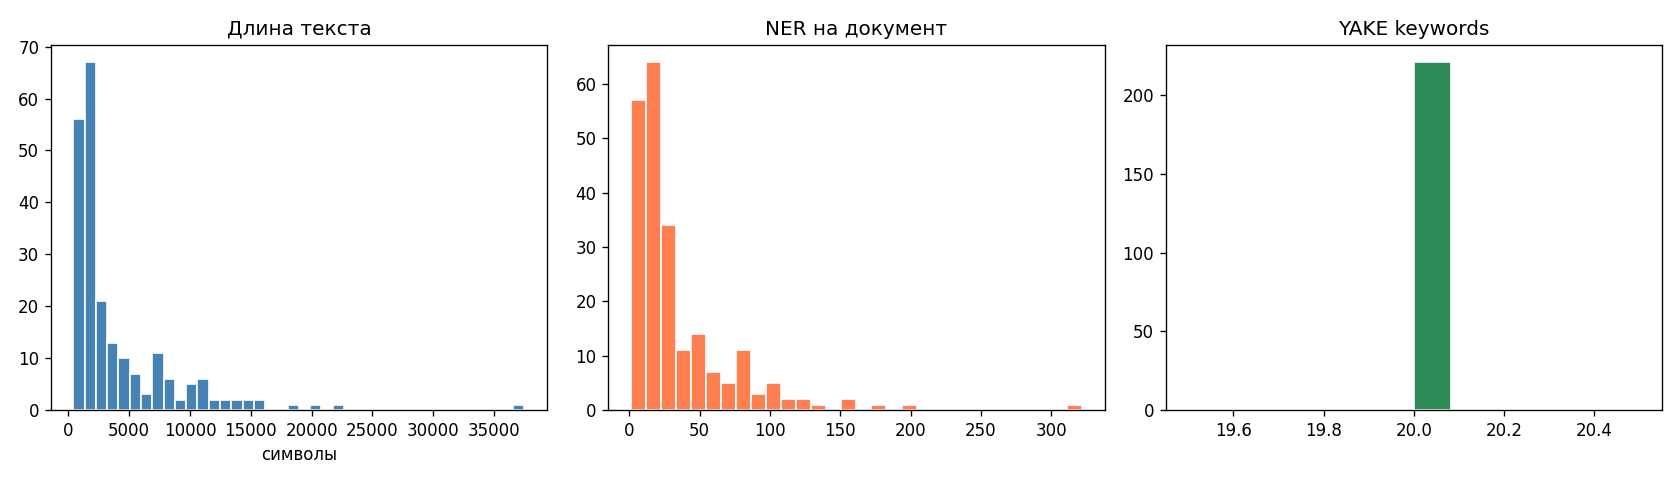

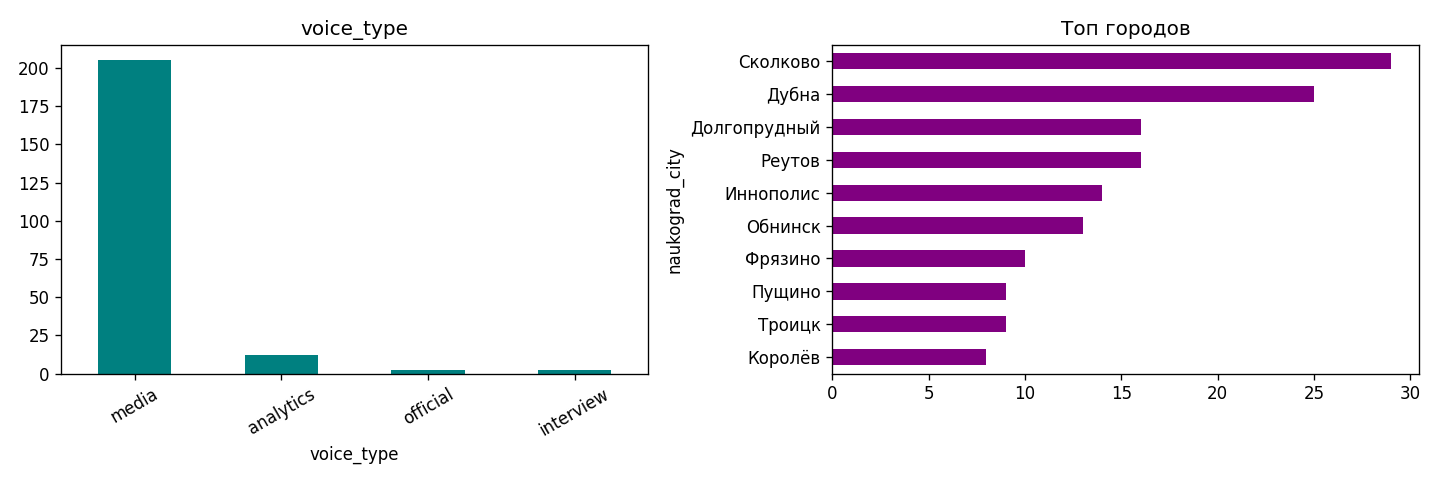

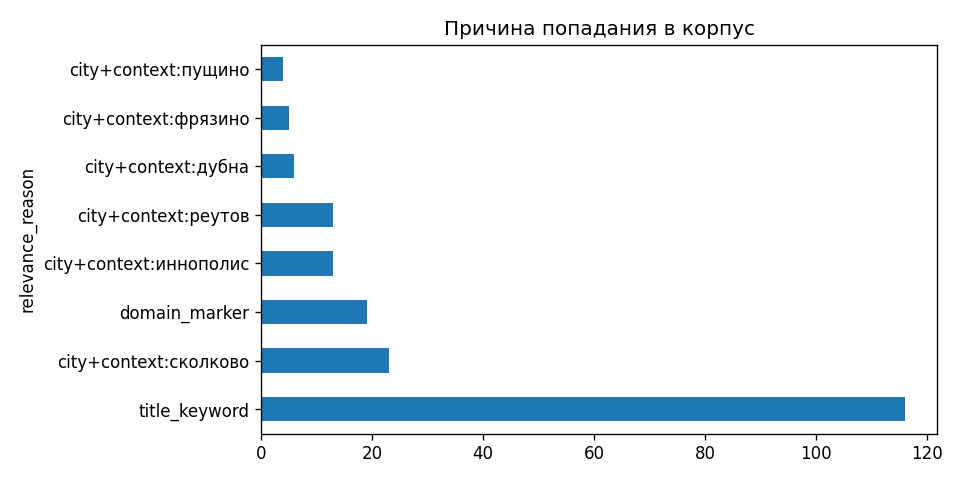

In [21]:
for name in ["01_corpus_distributions.png", "02_metadata.png", "03_relevance_reason.png"]:
    p = FIG / name
    if p.exists():
        display(Image(filename=str(p)))

## 3. NER и ключевики — доменная валидность

In [22]:
ent_c, kw_c = Counter(), Counter()
for doc in docs:
    for e in doc.get("entities", []):
        ent_c[e["text"].lower()] += 1
    for k in doc.get("keywords", []):
        kw_c[k.lower()] += 1

print("Топ-20 NER:")
display(pd.DataFrame(ent_c.most_common(20), columns=["entity", "count"]))
print("\nТоп-20 YAKE (часть шума — артефакт RSS):")
display(pd.DataFrame(kw_c.most_common(20), columns=["keyword", "count"]))

domain_ner = sum(1 for t, _ in ent_c.most_common(20) if any(x in t for x in ["дубн", "сколков", "наук", "нии", "ран", "обнинск"]))
print(f"\nДоменных сущностей в топ-20 NER: {domain_ner} (ожидаем ≥5)")

Топ-20 NER:


,entity,count
0,сколково,247
1,россии,245
2,кольцово,124
3,пущино,95
4,рф,92
5,московской области,84
6,иннополис,82
7,москвы,67
8,троицк,64
9,троицка,61



Топ-20 YAKE (часть шума — артефакт RSS):


,keyword,count
0,автор текста,33
1,сколково,20
2,россии,19
3,главная общество,17
4,российской федерации,14
5,фото,14
6,московской области,14
7,владимир острогожский,14
8,кольцово,12
9,главная общество автор,12



Доменных сущностей в топ-20 NER: 3 (ожидаем ≥5)


## 4. Сравнение графов

,nodes,edges,avg_degree,max_degree,components,density,pmi_median,edge_weight_median,edges_per_node
graph,,,,,,,,,
legacy_cooccurrence,253,317,2.505929,6,62,0.009944,5.7541,3.0,2.51
constructor,211,216,2.047393,6,63,0.009749,6.0062,2.0,2.05
graphrag_baseline,204,271,2.656863,13,30,0.013088,5.3275,2.0,2.66


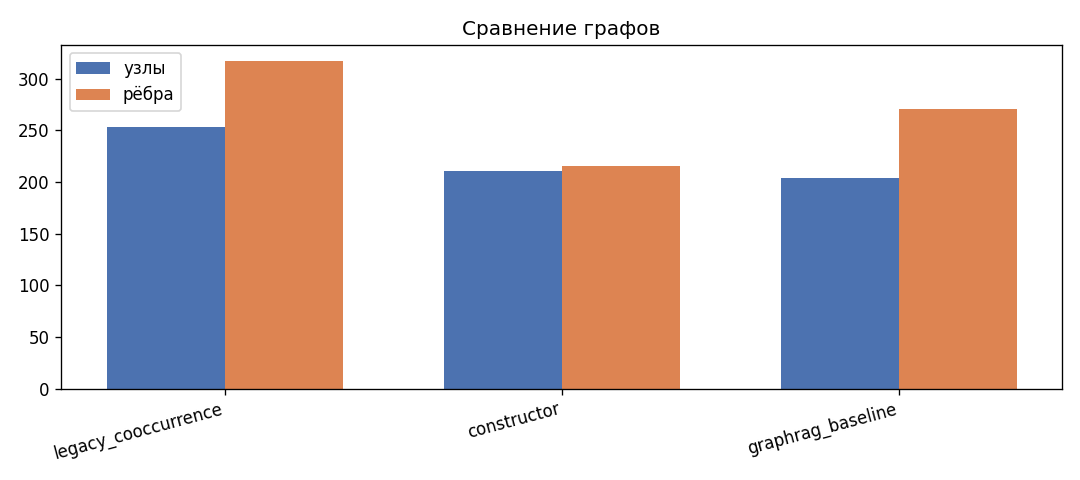

In [23]:
rows = []
for name, m in graph_metrics.items():
    if m:
        rows.append({"graph": name, **m})
display(pd.DataFrame(rows).set_index("graph"))

display(Image(filename=str(FIG / "04_graph_comparison.png")))

## 5. Визуализация сетей и сообществ

### constructor

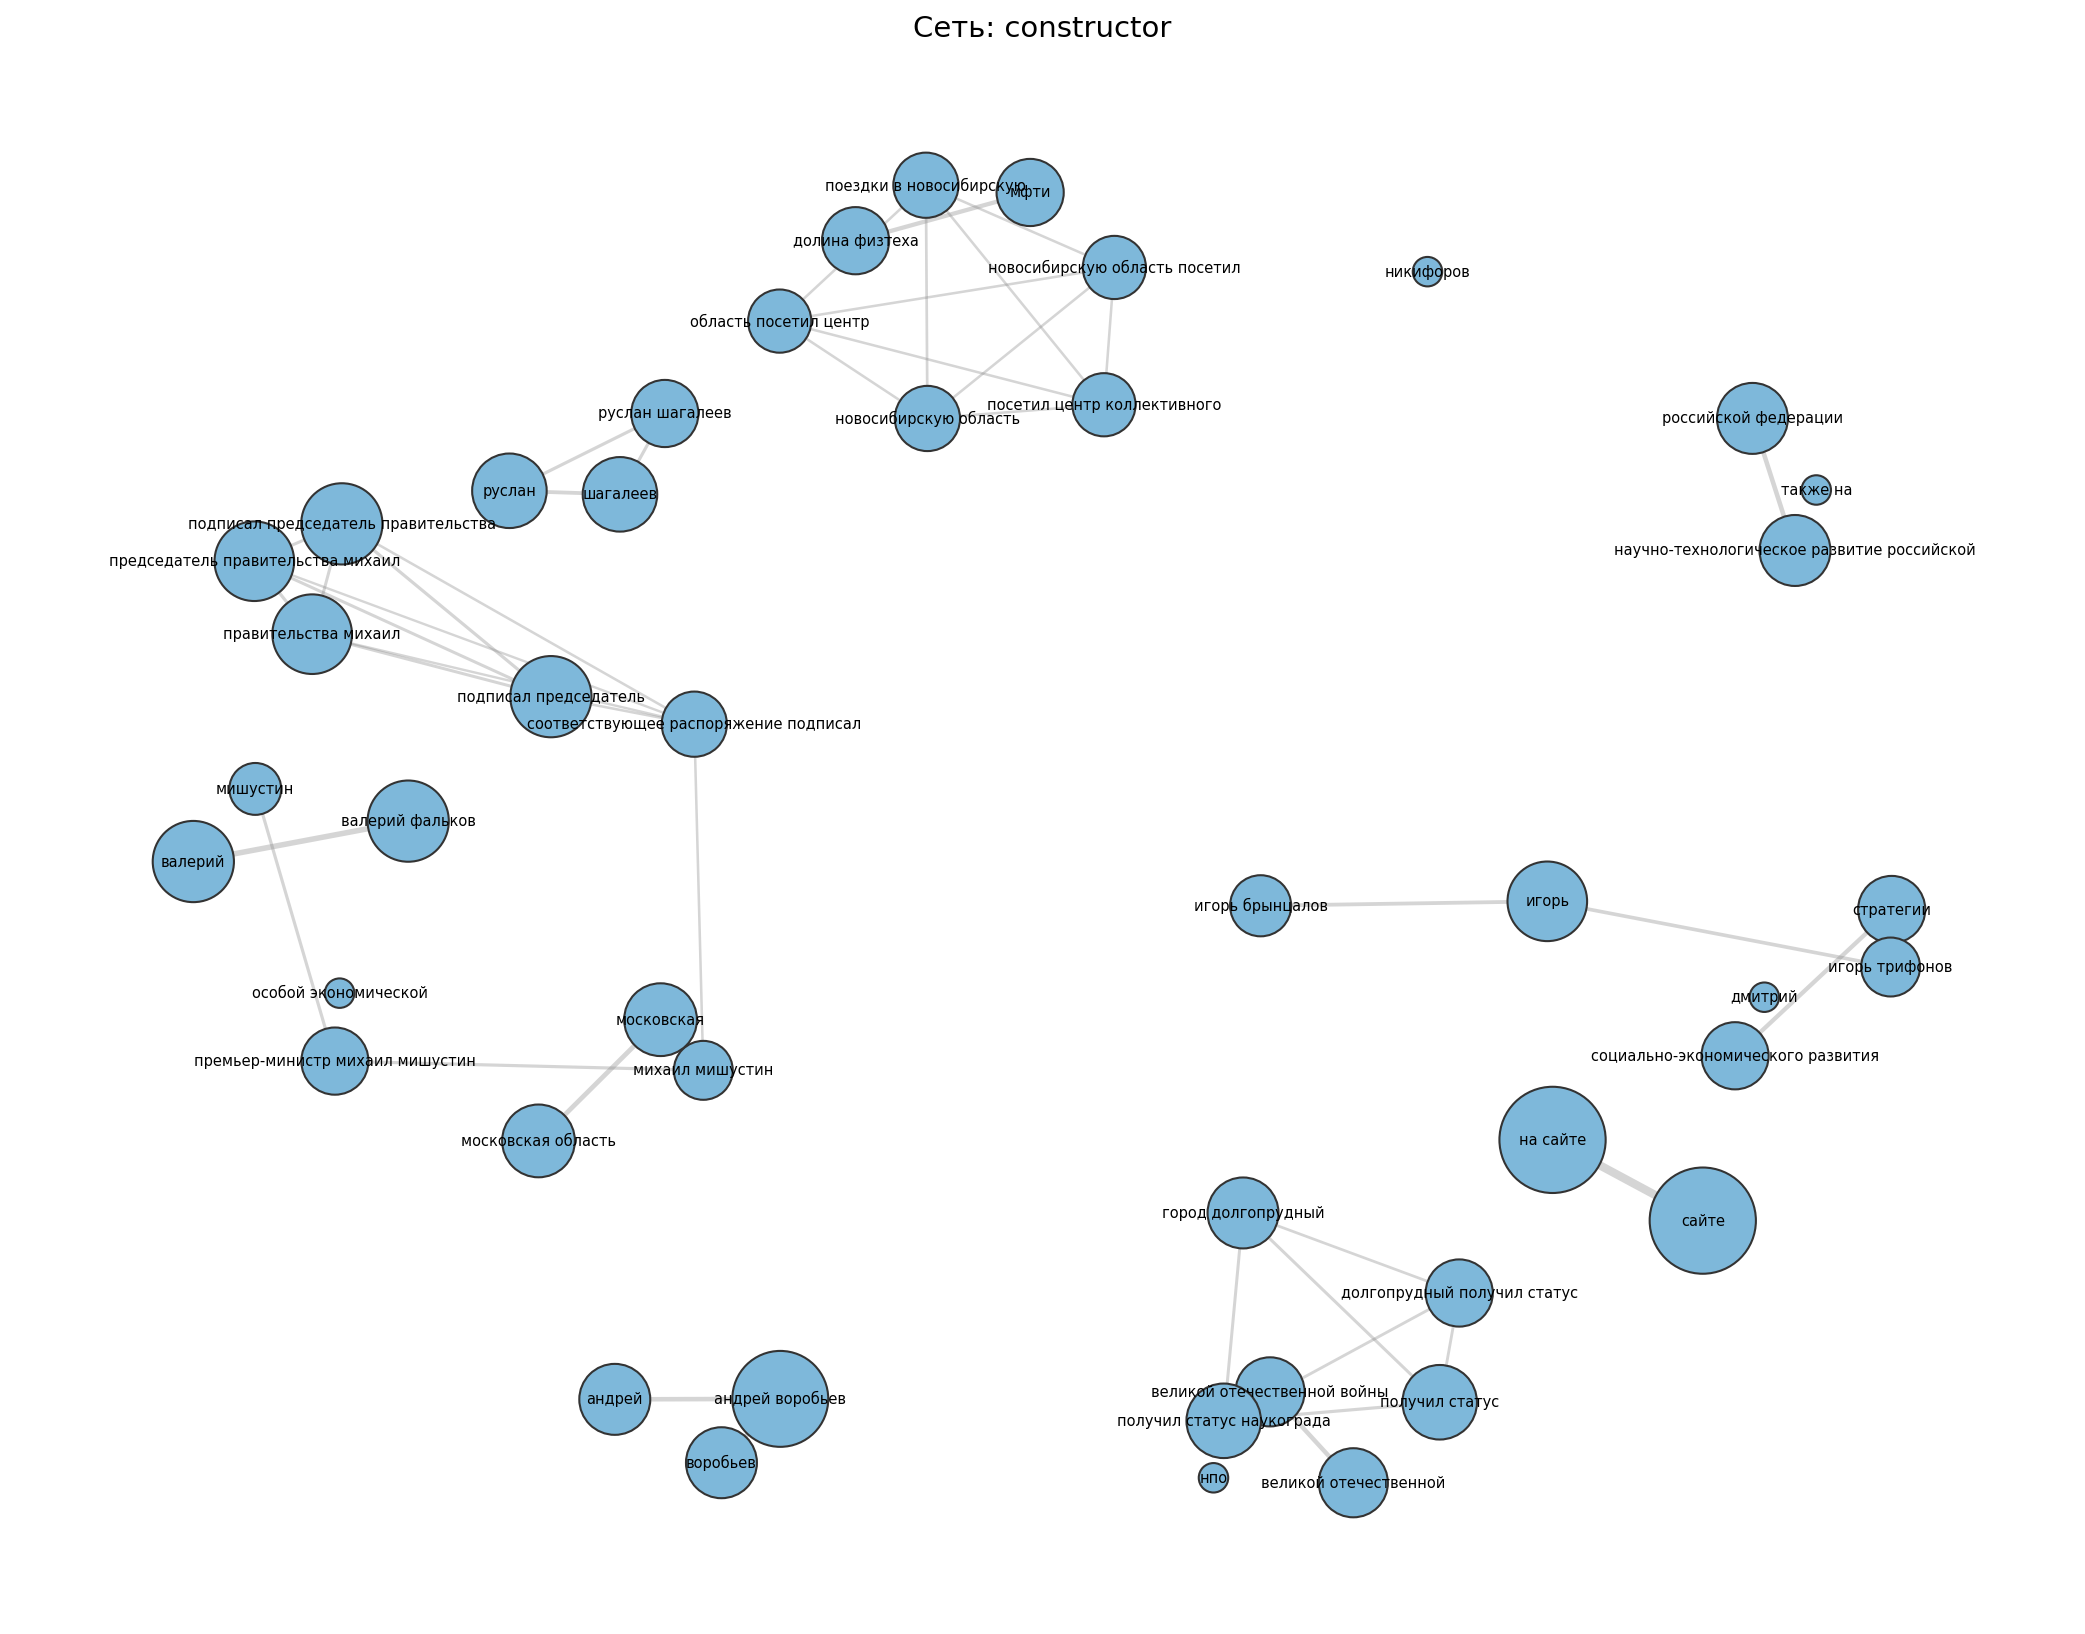

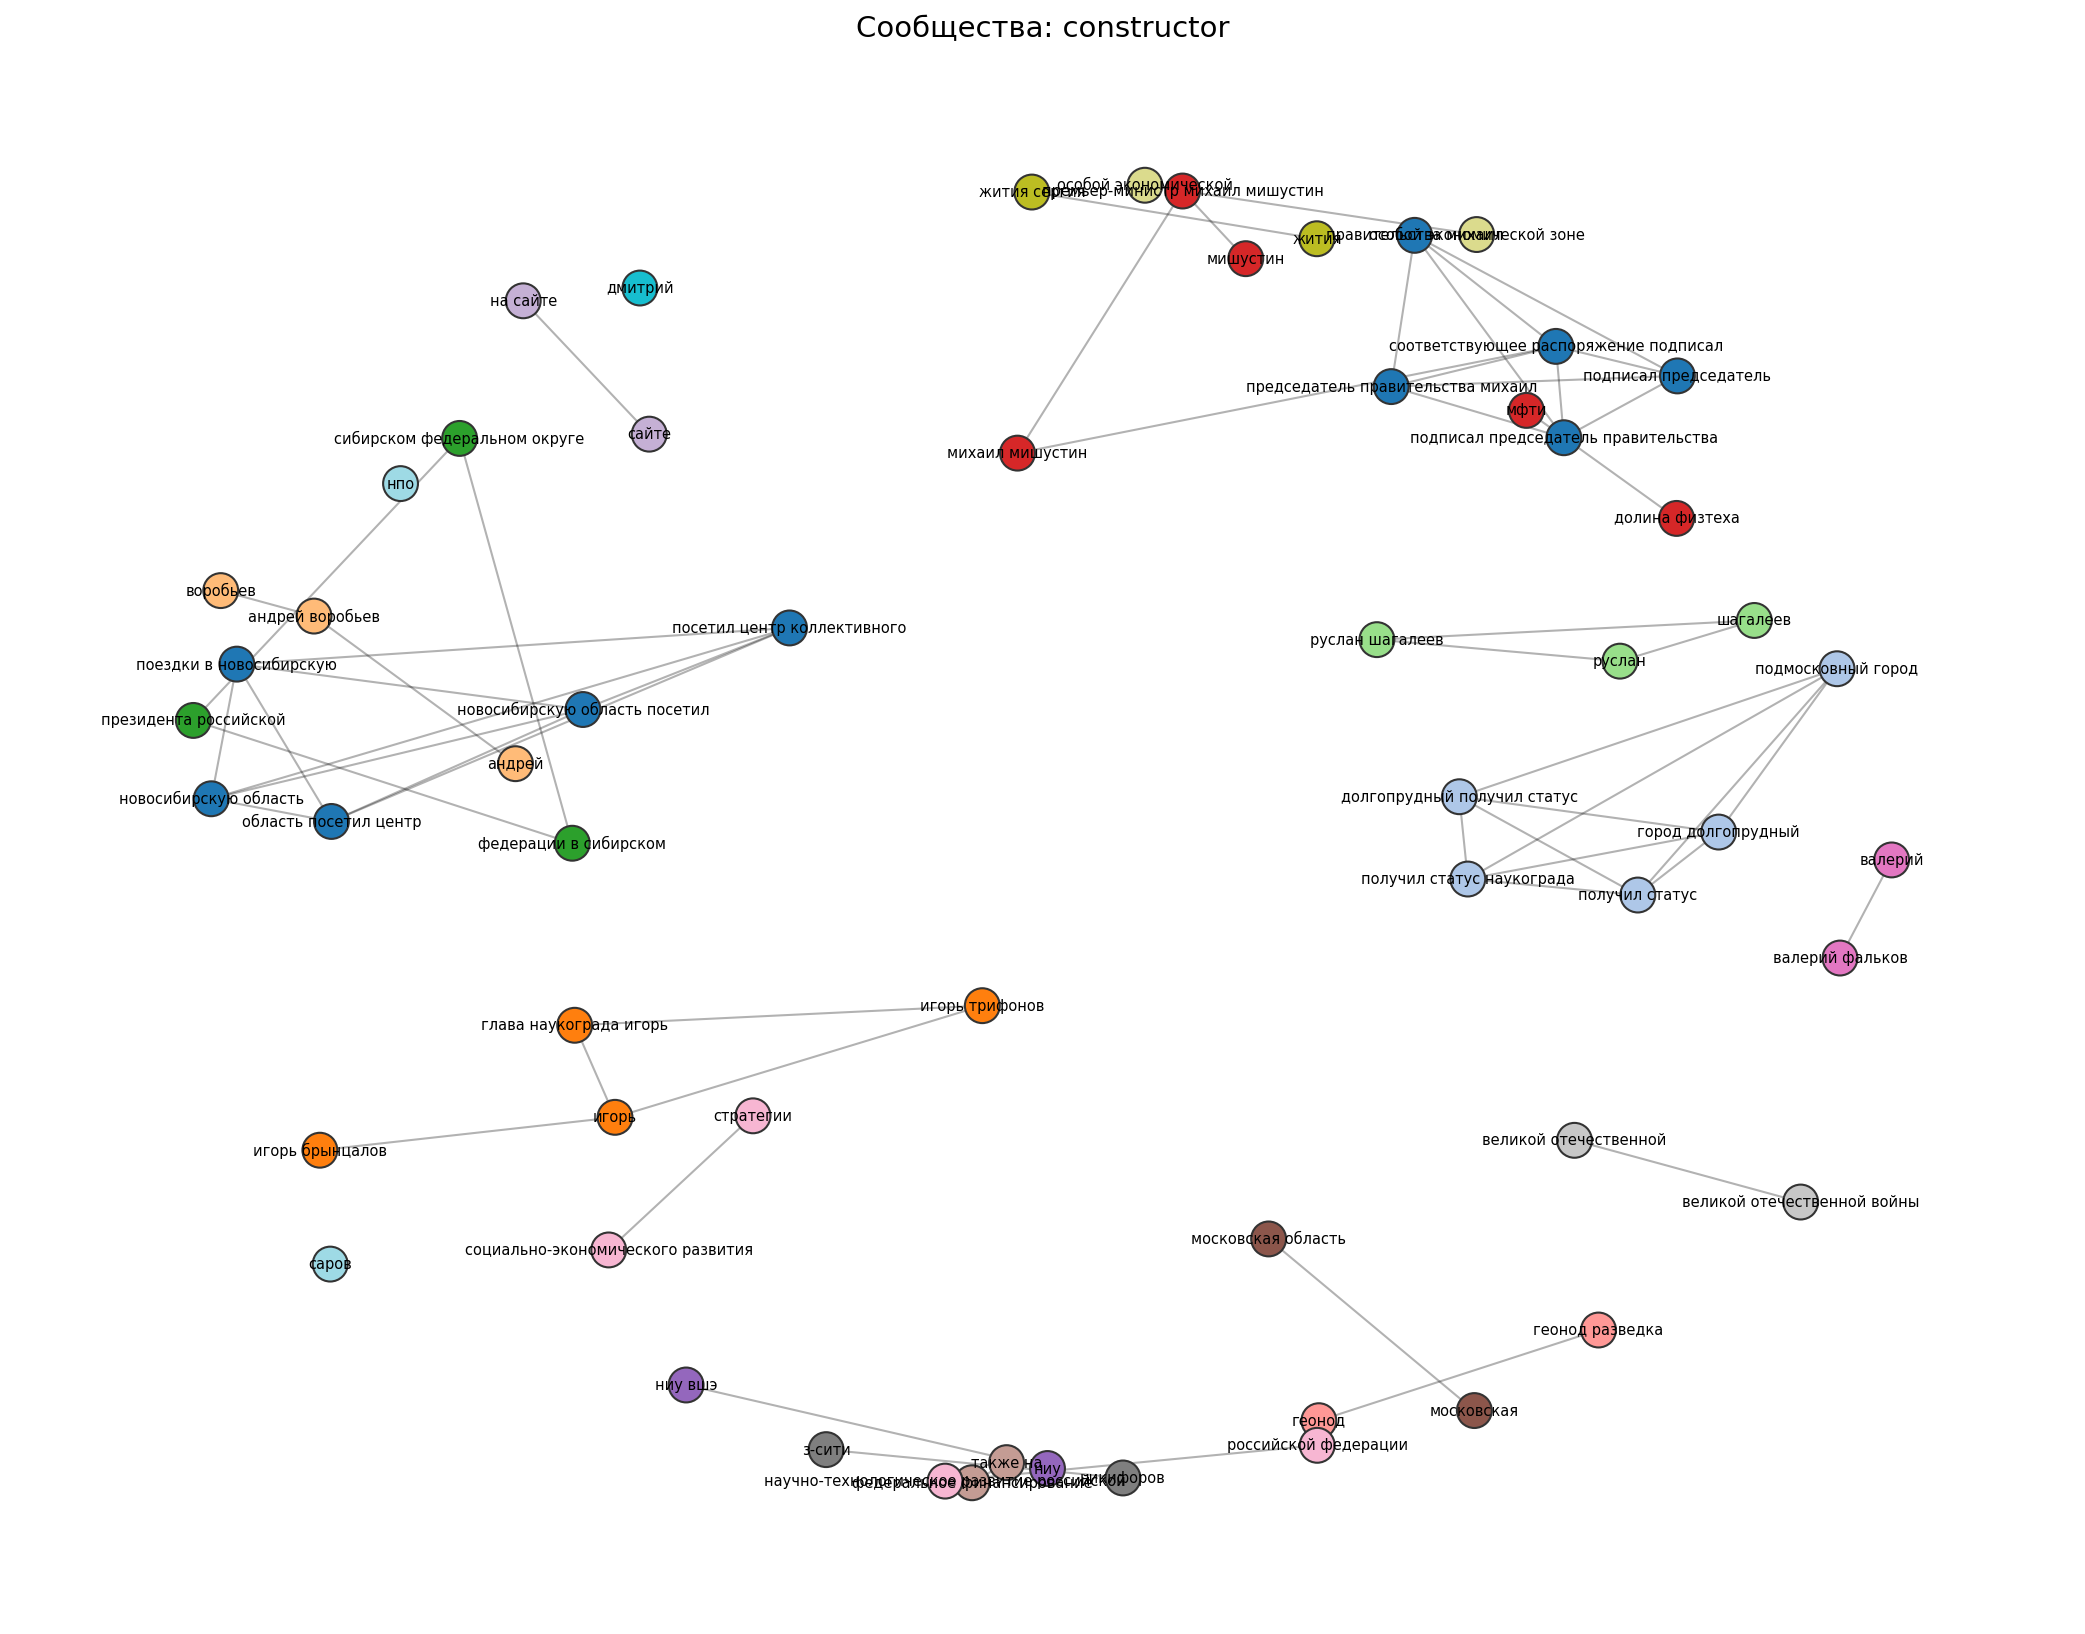

### legacy_cooccurrence

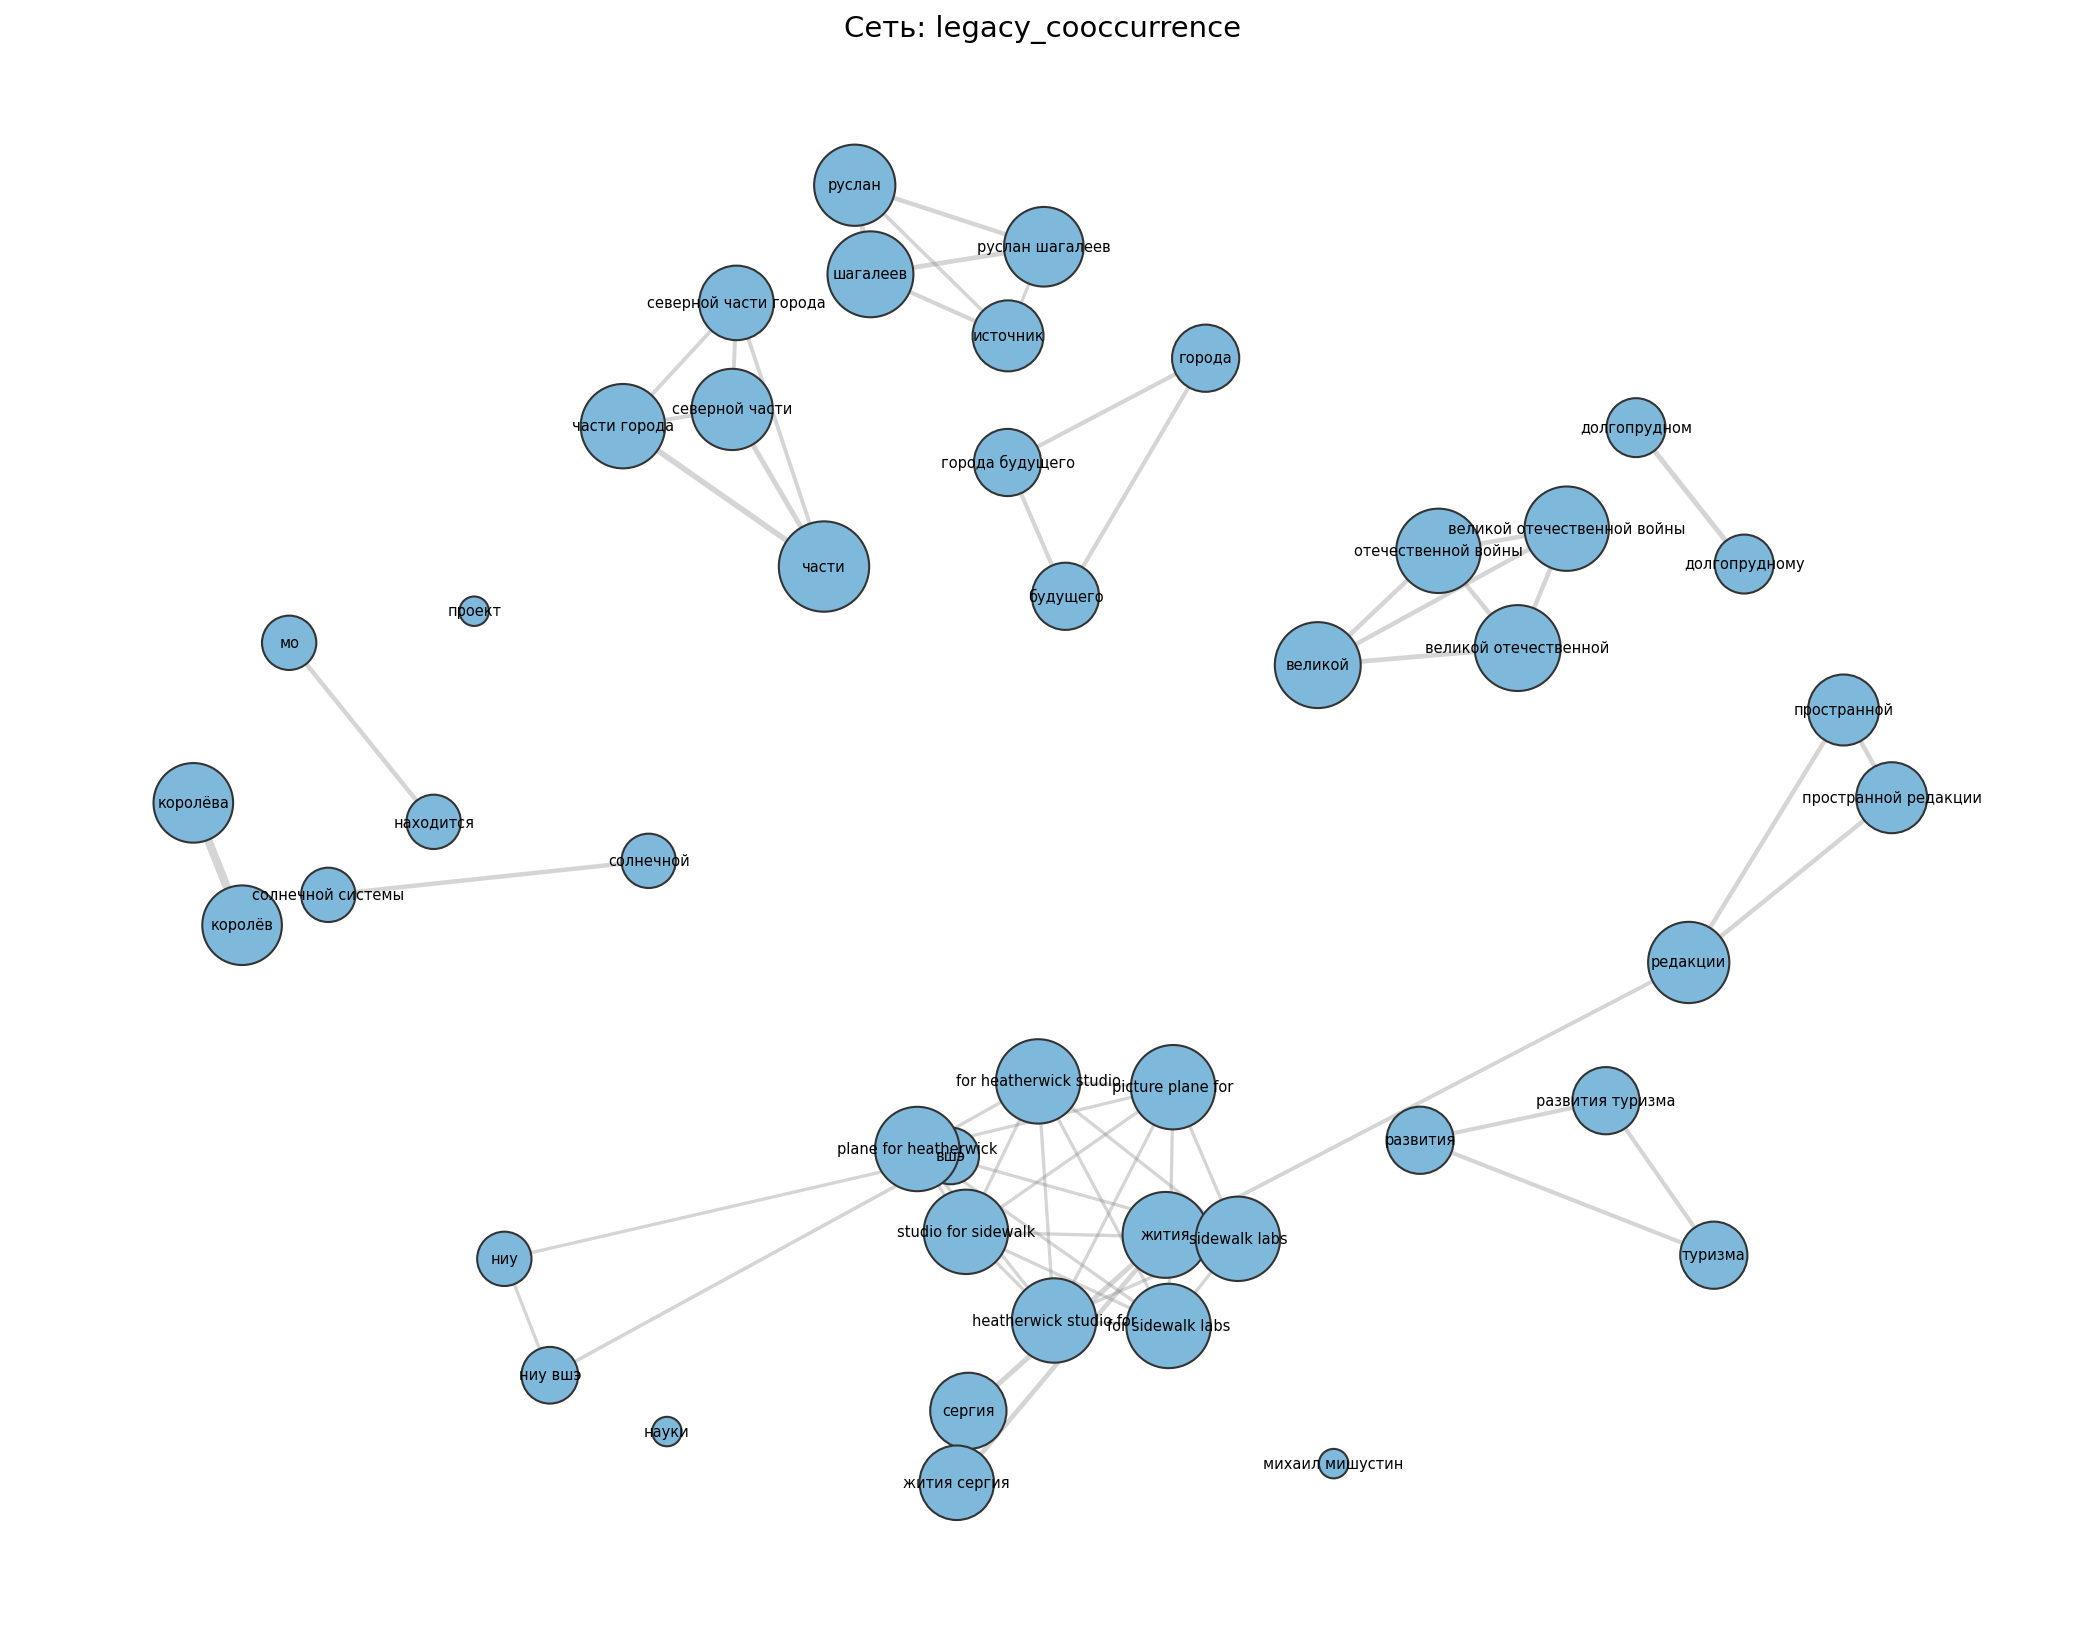

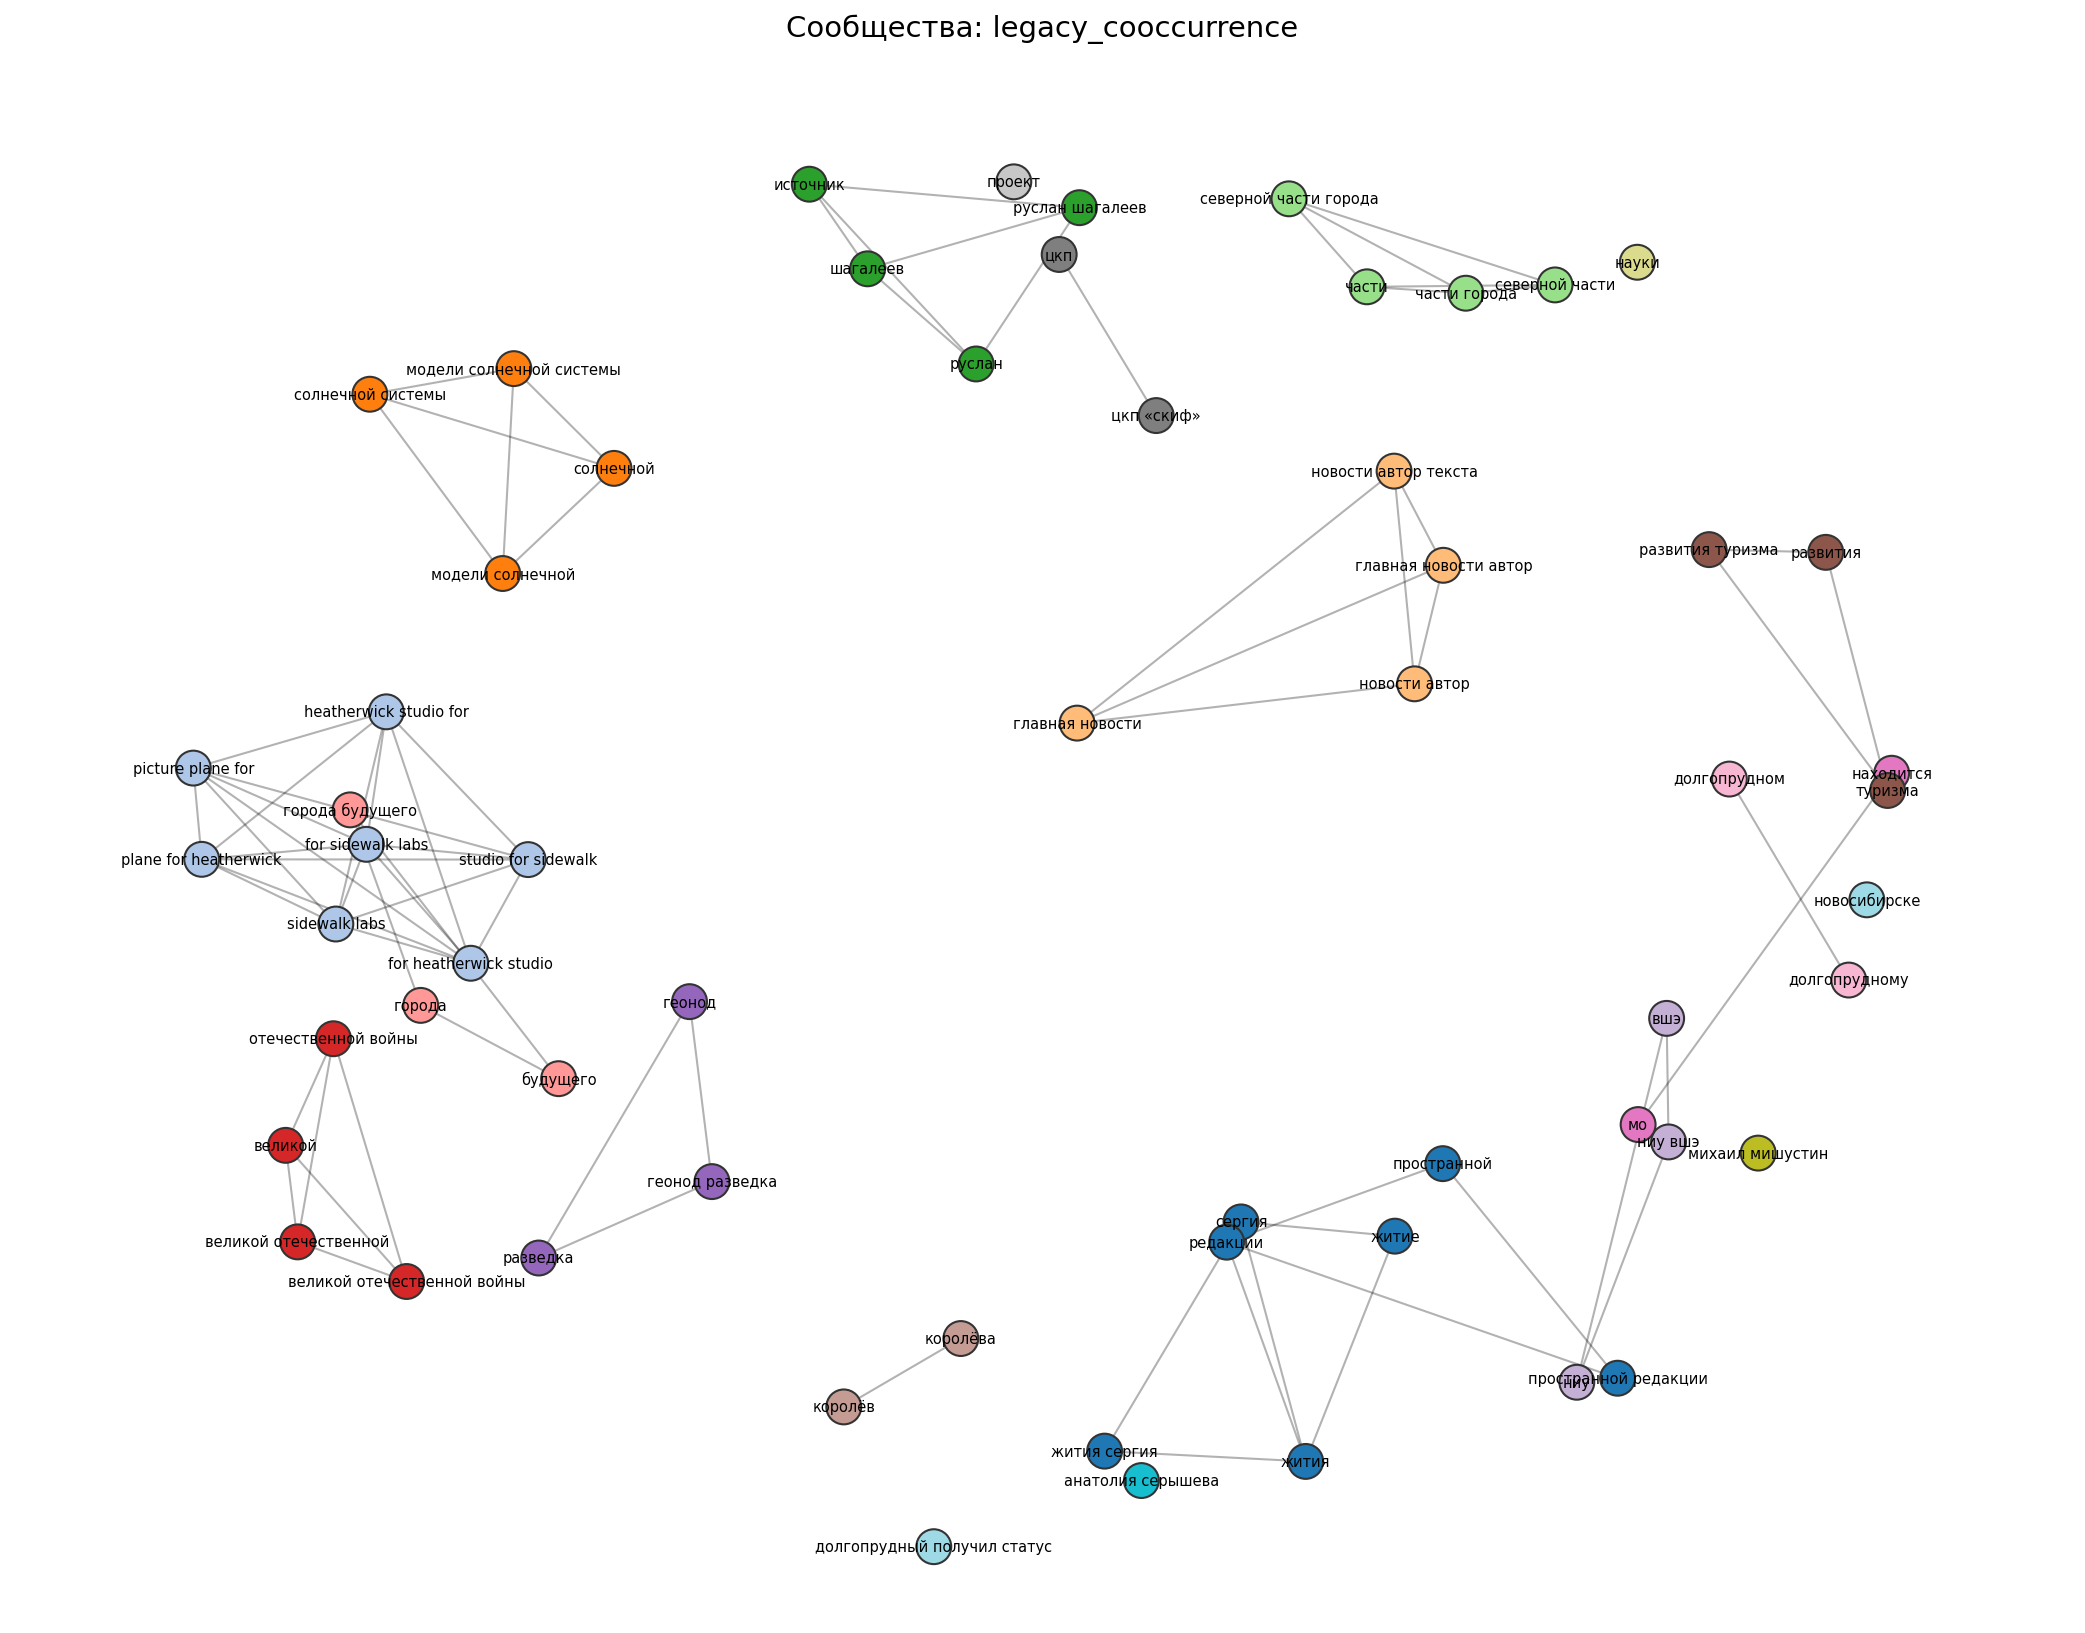

### graphrag_baseline

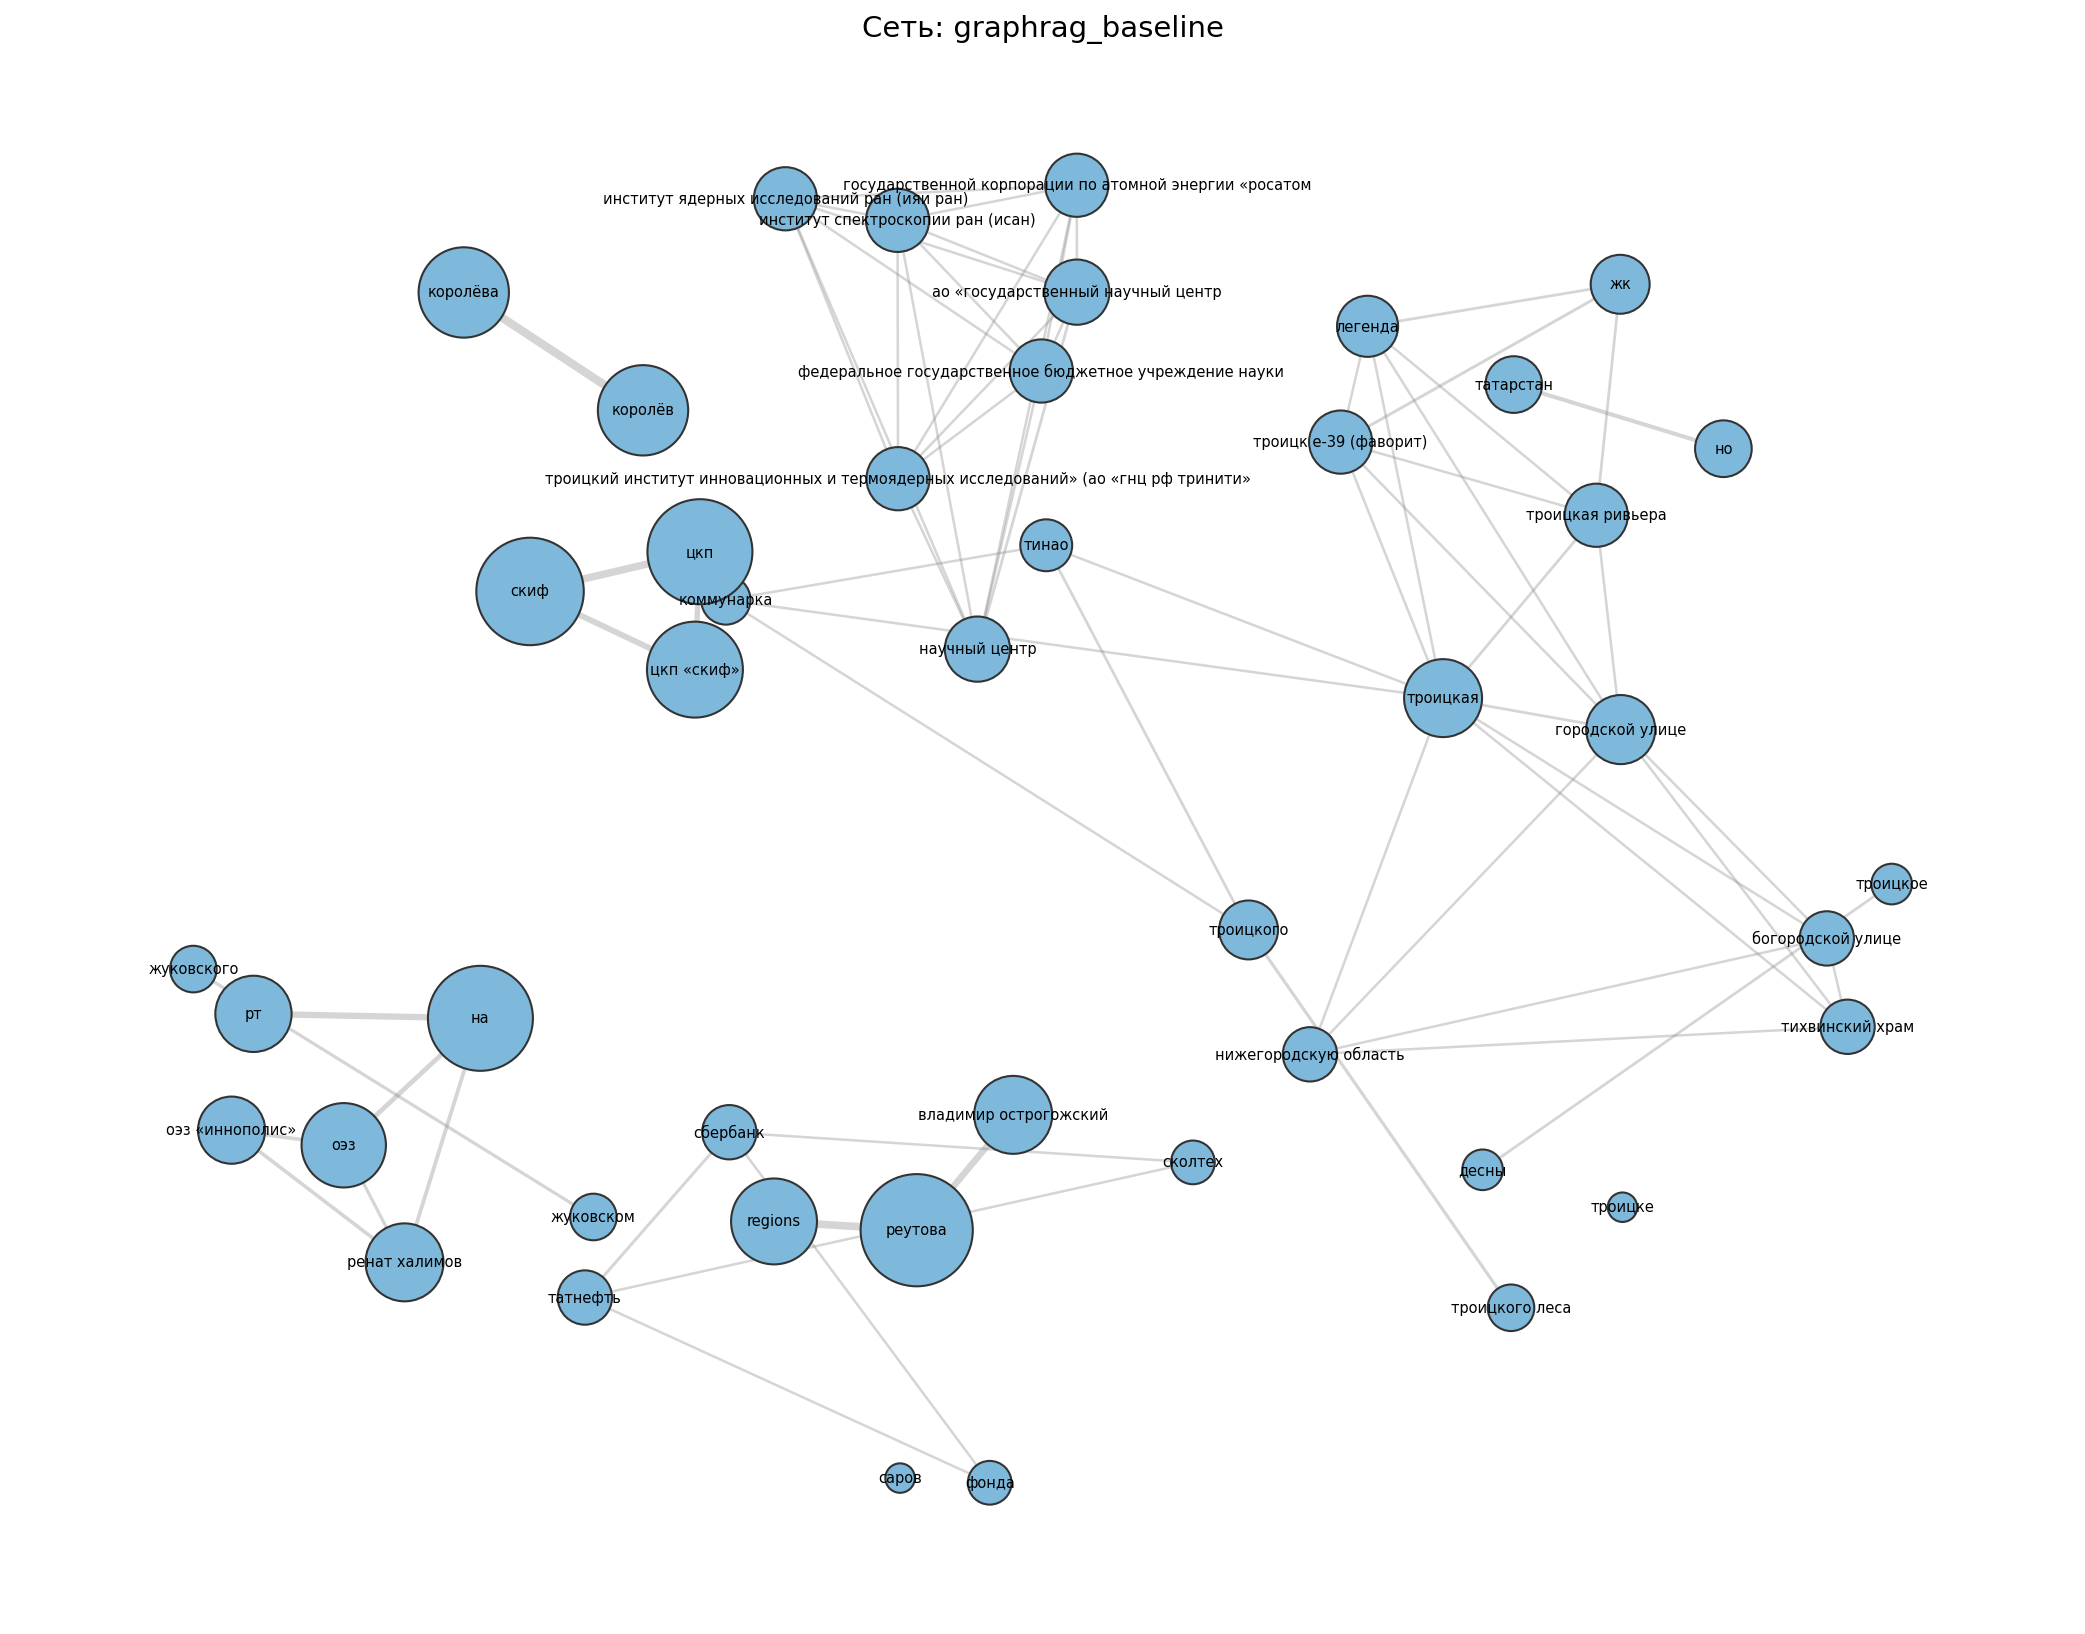

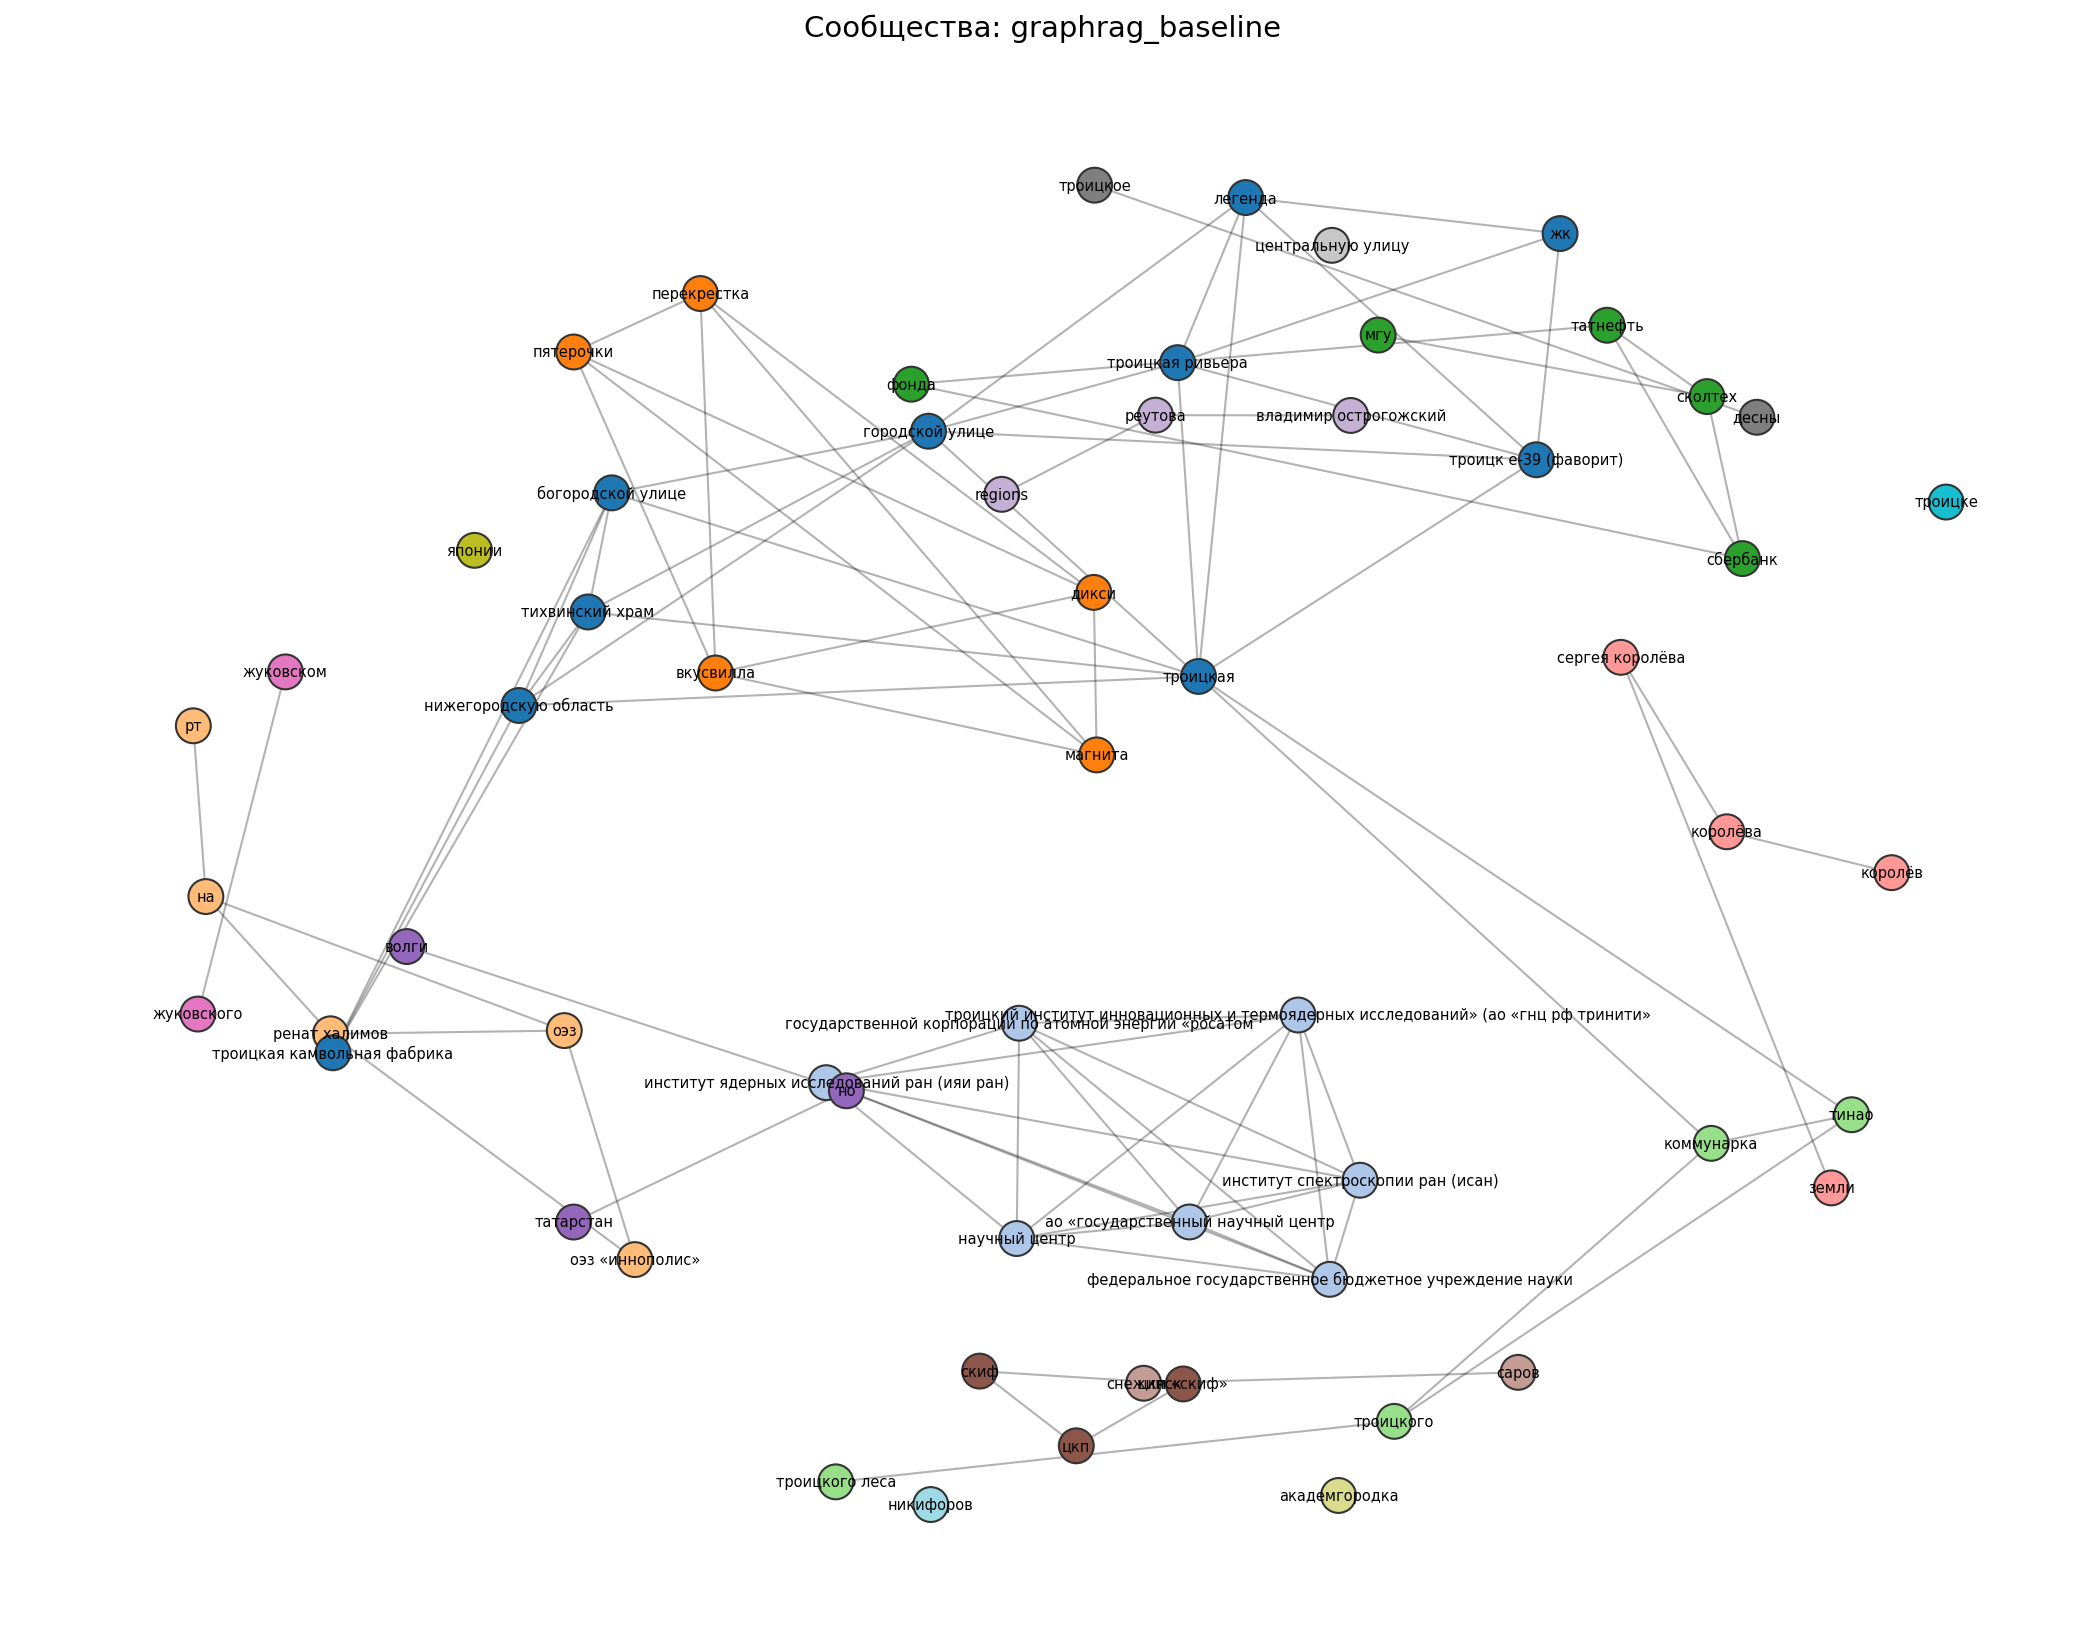

In [24]:
for gname in ["constructor", "legacy_cooccurrence", "graphrag_baseline"]:
    net = FIG / f"07_network_{gname}.png"
    comm = FIG / f"08_communities_{gname}.png"
    if net.exists():
        display(Markdown(f"### {gname}"))
        display(Image(filename=str(net)))
        if comm.exists():
            display(Image(filename=str(comm)))

## 6. Конструктор: центральность и «жареные» связи

In [25]:
npth, epth = PATHS["constructor"]
edges = pd.read_csv(epth)
G = nx.from_pandas_edgelist(edges, "source", "target", edge_attr=True)

deg = sorted(G.degree(weight="weight"), key=lambda x: x[1], reverse=True)[:15]
bet = sorted(nx.betweenness_centrality(G, weight="weight").items(), key=lambda x: x[1], reverse=True)[:15]
print("Топ degree:", deg)
print("Топ betweenness:", bet)

if "surprisal" in edges.columns:
    print("\nТоп surprisal (жареные связи):")
    display(edges.nlargest(10, "surprisal")[["source", "target", "surprisal", "weight", "methods"]])

rhet = edges[edges["methods"].astype(str).str.contains("rhetorical", na=False)]
print(f"\nРиторических рёбер: {len(rhet)}")
if len(rhet):
    display(rhet.head(8)[["source", "target", "relation", "weight"]])

Топ degree: [('на сайте', 40), ('сайте', 40), ('андрей воробьев', 37), ('игорь', 30), ('валерий', 29), ('получил статус наукограда', 25), ('воробьев', 24), ('получил статус', 23), ('город долгопрудный', 23), ('подписал председатель правительства', 22), ('подписал председатель', 22), ('валерий фальков', 22), ('московская', 21), ('московская область', 21), ('председатель правительства михаил', 21)]
Топ betweenness: [('соответствующее распоряжение подписал', 0.0011847801321485532), ('михаил мишустин', 0.0009341535657325131), ('сибирском федеральном округе', 0.0009113693324219641), ('рабочая встреча полномочного', 0.0008202323991797676), ('главных центров', 0.0007746639325586694), ('игорь', 0.0007518796992481203), ('новосибирске', 0.0006379585326953748), ('глава наукограда игорь', 0.0005468215994531784), ('россии михаил', 0.0005468215994531784), ('мособлдумы игорь брынцалов', 0.0005468215994531784), ('город долгопрудный', 0.0005012531328320802), ('анатолий серышев посетил', 0.0004708741550

,source,target,surprisal,weight,methods
1,ссср,ниизм,17.5961,2,"['anaphora', 'cooccurrence', 'perplexity']"
3,саров,нижегородской области,17.5961,2,"['cooccurrence', 'perplexity']"
6,новосибирске,рабочая встреча полномочного,17.5961,2,"['cooccurrence', 'perplexity']"
7,академии наук,ниизм,17.5961,2,"['anaphora', 'cooccurrence', 'perplexity']"
8,академии наук,министерства науки,17.5961,2,"['cooccurrence', 'emotional', 'perplexity']"
9,черноголовке,институт физики,17.5961,2,"['cooccurrence', 'emotional', 'perplexity']"
10,королев,королевской больницы,17.5961,4,"['cooccurrence', 'emotional', 'perplexity']"
14,тасс,рудольф дик,17.5961,2,"['cooccurrence', 'perplexity']"
15,тасс,наукограда николай красников,17.5961,2,"['cooccurrence', 'emotional', 'perplexity']"
17,страх,юлия коротун,17.5961,3,"['anaphora', 'cooccurrence', 'perplexity']"



Риторических рёбер: 12


,source,target,relation,weight
2,саров,снежинск,contrast,9
84,на сайте,сайте,contrast,40
93,андрей,андрей воробьев,contrast,16
99,андрей воробьев,воробьев,contrast,16
172,института развития городов,наиля зиннатуллина,contrast,4
173,института развития городов,бизнес online,contrast,3
174,наиля зиннатуллина,бизнес online,contrast,3
175,никифоров,з-сити,contrast,12


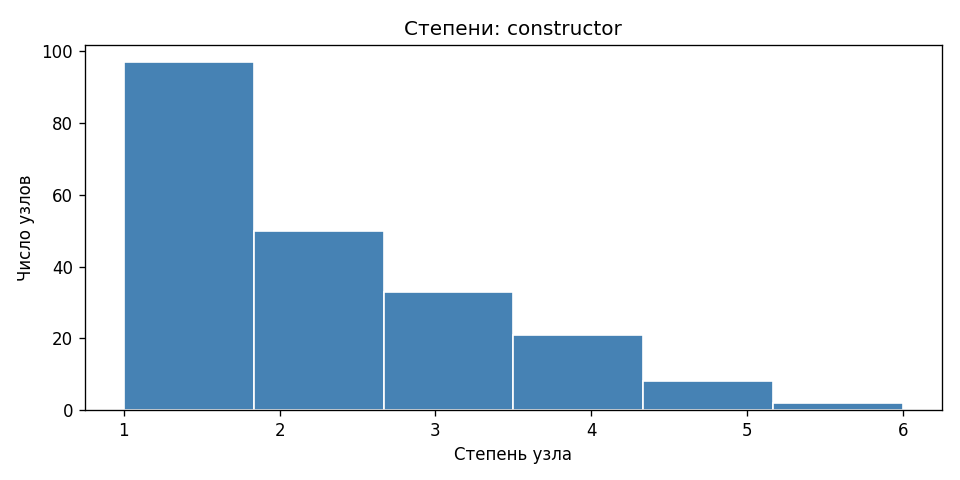

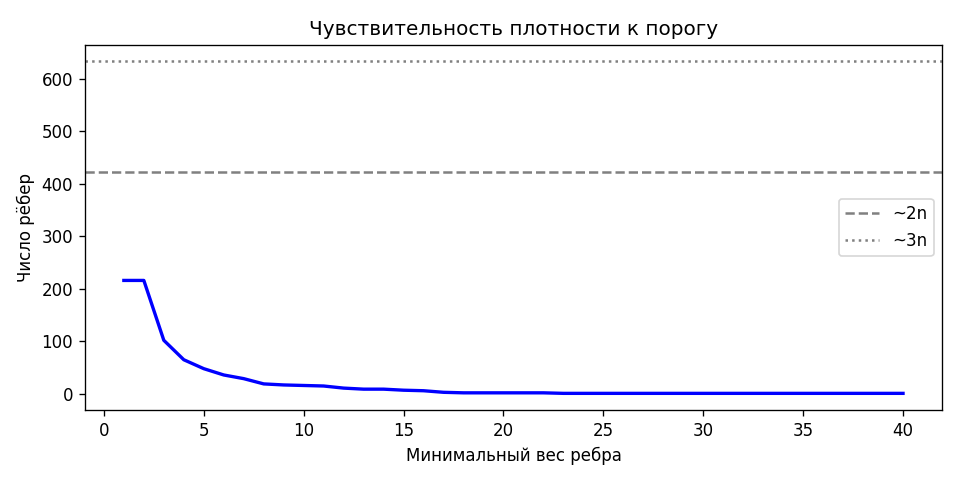

In [26]:
for name in ["05_degree_constructor.png", "06_threshold_constructor.png"]:
    p = FIG / name
    if p.exists():
        display(Image(filename=str(p)))